In [ ]:
import math
import pandas as pd


DB_PATH = "runs_index.csv"

DB = pd.read_csv(DB_PATH, index_col=0)


PROBLEMS = ['vanderpol', 'pollu', 'rober', 'orego', 'hires', 'davis-skodje']


#Filter out old runs. 

Images of Van Der Pol. 
Collocation + DerivMatch + Shooting is the best configuration.
run `run_E9ArQetU`

DerivMatch + Shooting + GELU-scaled is the one we want to compare with. 
`run_2cXb4Ci9`

In [4]:
stiff_run_vdp = "run_E9ArQetU" #best by trahjectory_test metric
stiff_run_vdp = "run_5wDGqVf4" #best by spec_train metric
gelu_run_vdp = "run_2cXb4Ci9"

### Trajectory + spectral fit figures (2x2, both species)

For each run directory above, pull `ctx`/`θ` back out of `state.jld2` (via a small
Julia helper that reuses `rollout`/`eigenvalues`/`extrapolation_ctx` from
`StiffNN`), dump the train/test scatter + dense fit curves to CSV, and re-plot
them here with matplotlib. Each figure is a 2x2 grid: rows are the two van der
Pol species ($y_1$, $y_2$), columns are the trajectory fit and the spectral
(eigenvalue) fit. The velocity-field panel is intentionally omitted.

In [5]:
import subprocess
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
RUNS_DIR = REPO_ROOT / "data" / "runs"
EXTRACT_SCRIPT = REPO_ROOT / "src" / "scripts" / "local" / "extract_run_data.jl"
EXTRACT_DIR = REPO_ROOT / "analysis" / "extracted"
FIG_DIR = REPO_ROOT / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def extract_run(run_id, force=False):
    """Runs src/scripts/local/extract_run_data.jl on a run dir, caching the CSVs."""
    out_dir = EXTRACT_DIR / run_id
    if force or not (out_dir / "meta.csv").exists():
        out_dir.mkdir(parents=True, exist_ok=True)
        subprocess.run(
            ["julia", f"--project={REPO_ROOT}", str(EXTRACT_SCRIPT),
             str(RUNS_DIR / run_id), str(out_dir)],
            check=True, cwd=REPO_ROOT,
        )
    return out_dir


for _run in {stiff_run_vdp, gelu_run_vdp}:
    extract_run(_run)

wrote /Users/theoxenakis/Downloads/GoCart/MIT/JuliaLab/BVPsolver/analysis/extracted/run_5wDGqVf4


In [10]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10.5,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Colorblind-safe roles (validated categorical slots, see dataviz skill palette).
COLOR_TRAIN = "#000000"   # observed data used for fitting
COLOR_TEST = "#2a78d6"    # held-out / extrapolation data (categorical slot 1, blue)
COLOR_FIT = "#eb6834"     # model prediction (categorical slot 2, orange)
COLOR_SPLIT = "#8a8a8a"   # train/test boundary
MARKER_KW = dict(s=6, linewidths=0.4, alpha=0.85, facecolors="none")


def plot_vdp_run(run_id, title, save_name=None):
    out_dir = EXTRACT_DIR / run_id
    meta = pd.read_csv(out_dir / "meta.csv", index_col="key")["value"]
    T_train = float(meta["T_train"])

    traj_dense = pd.read_csv(out_dir / "traj_dense.csv")
    traj_data = pd.read_csv(out_dir / "traj_data.csv")
    spectral = pd.read_csv(out_dir / "spectral.csv")

    traj_train, traj_test = traj_data[traj_data.is_train == 1], traj_data[traj_data.is_train == 0]
    spec_train, spec_test = spectral[spectral.is_train == 1], spectral[spectral.is_train == 0]

    fig, axes = plt.subplots(2, 2, figsize=(8.5, 5.6), sharex=True)

    for row, species in enumerate((1, 2)):
        ycol = f"y{species}"
        ax = axes[row, 0]
        ax.scatter(traj_train["t"], traj_train[ycol], edgecolors=COLOR_TRAIN, zorder=3,
                   label="train data" if row == 0 else None, **MARKER_KW)
        ax.scatter(traj_test["t"], traj_test[ycol], edgecolors=COLOR_TEST, zorder=3,
                   label="test data" if row == 0 else None, **MARKER_KW)
        ax.plot(traj_dense["t"], traj_dense[ycol], color=COLOR_FIT, lw=1.4, zorder=2,
                label="neural ODE" if row == 0 else None)
        ax.axvline(T_train, color=COLOR_SPLIT, ls="--", lw=0.9, zorder=1,
                   label="train/test split" if row == 0 else None)
        ax.set_ylabel(f"$y_{{{species}}}$")

        lcol_true, lcol_learned = f"lambda{species}_true", f"lambda{species}_learned"
        ax2 = axes[row, 1]
        ax2.scatter(spec_train["t"], spec_train[lcol_true], edgecolors=COLOR_TRAIN, zorder=3, **MARKER_KW)
        ax2.scatter(spec_test["t"], spec_test[lcol_true], edgecolors=COLOR_TEST, zorder=3, **MARKER_KW)
        ax2.plot(spectral["t"], spectral[lcol_learned], color=COLOR_FIT, lw=1.4, zorder=2)
        ax2.axvline(T_train, color=COLOR_SPLIT, ls="--", lw=0.9, zorder=1)
        ax2.set_ylabel(rf"$|\lambda_{{{species}}}|$")

    axes[0, 0].set_title("Trajectory fit")
    axes[0, 1].set_title("Spectral fit")
    axes[1, 0].set_xlabel("$t$")
    axes[1, 1].set_xlabel("$t$")

    fig.tight_layout(rect=(0, 0, 1, 0.88))
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False,
               bbox_to_anchor=(0.5, 0.965))
    fig.suptitle(title, y=1.0, fontsize=12)

    if save_name:
        fig.savefig(FIG_DIR / save_name)
    return fig

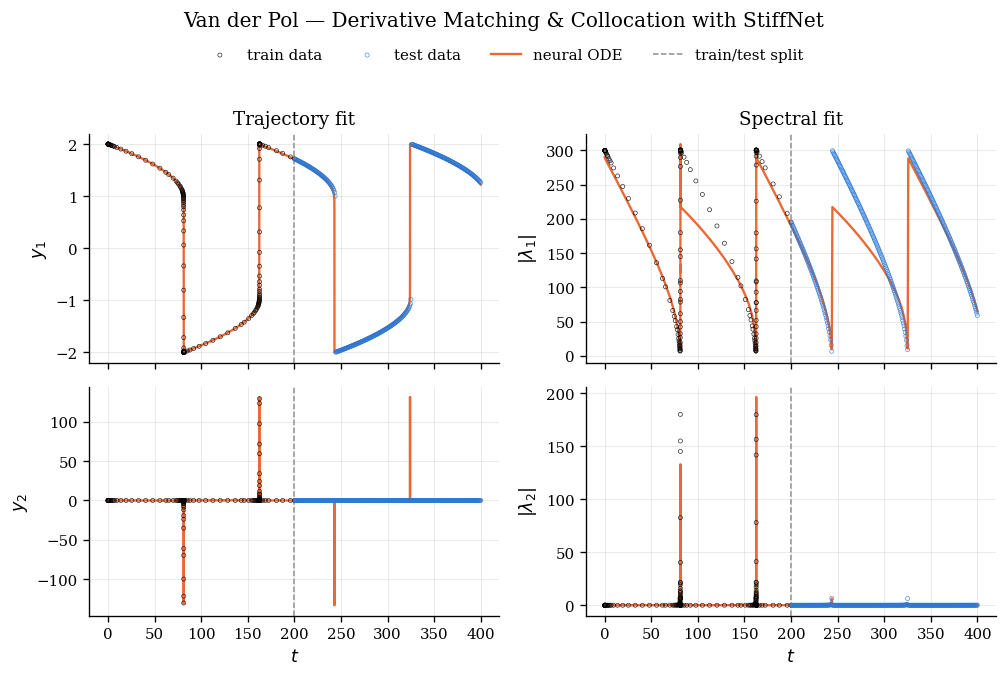

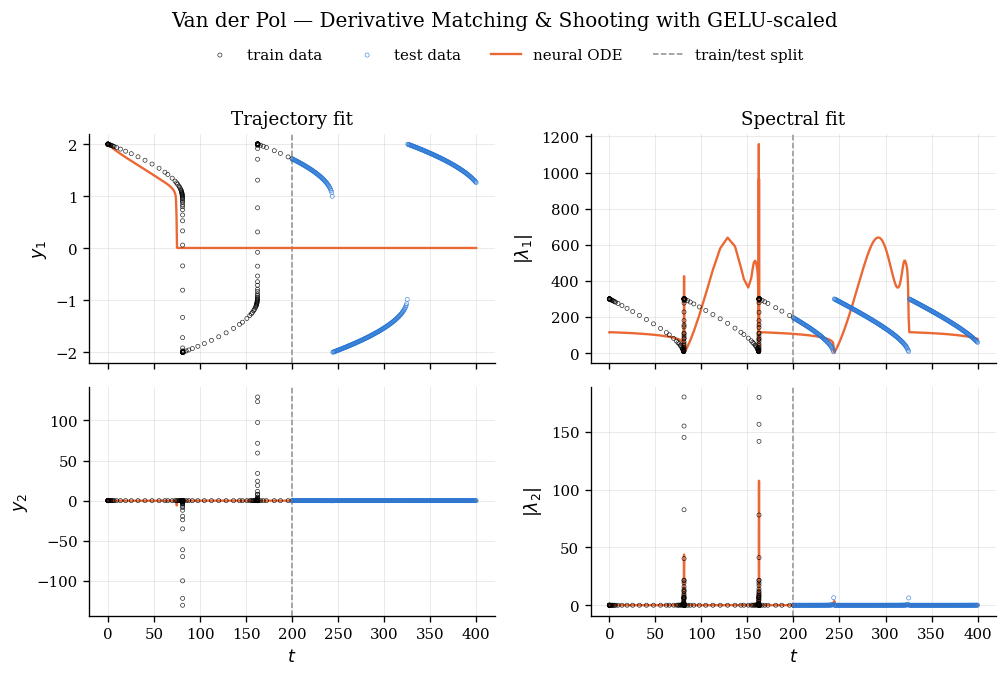

In [11]:
fig_stiff = plot_vdp_run(
    stiff_run_vdp,
    "Van der Pol — Derivative Matching & Collocation with StiffNet",
    save_name="vanderpol_stiff_collocation_summary.png",
)
fig_gelu = plot_vdp_run(
    gelu_run_vdp,
    "Van der Pol — Derivative Matching & Shooting with GELU-scaled",
    save_name="vanderpol_gelu_shooting_summary.png",
)
plt.show()